In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
%pip install scikit-learn


   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 4.3 MB/s eta 0:00:02
   --------- ------------------------------ 1.8/8.1 MB 6.0 MB/s eta 0:00:02
   ---------------- ----------------------- 3.4/8.1 MB 6.1 MB/s eta 0:00:01
   ----------------------- ---------------- 4.7/8.1 MB 6.3 MB/s eta 0:00:01
   ---------------------------- ----------- 5.8/8.1 MB 6.4 MB/s eta 0:00:01
   ---------------------------------- ----- 7.1/8.1 MB 6.0 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 6.1 MB/s  0:00:01
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   - -------------------------------------- 1.3/37.3 MB 6.2 MB/s eta 0:00:06
   -- ------------------------------------- 2.6/37.3 MB 6.6 MB/s eta 0:00:06
   --- ------------------------------------ 3.1/37.3 MB 6.5 MB/s eta 0:00:06
   ----- ---------------------------------- 4.7/37.3 MB 6.0 MB/s eta 0:00:06
   ------ --------------


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Analysing data (Bank.csv)

In [4]:
data = pd.read_csv("bank.csv",sep=";")
df = pd.DataFrame(data)
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,33,services,married,secondary,no,-333,yes,no,cellular,30,jul,329,5,-1,0,unknown,no
4517,57,self-employed,married,tertiary,yes,-3313,yes,yes,unknown,9,may,153,1,-1,0,unknown,no
4518,57,technician,married,secondary,no,295,no,no,cellular,19,aug,151,11,-1,0,unknown,no
4519,28,blue-collar,married,secondary,no,1137,no,no,cellular,6,feb,129,4,211,3,other,no


In [5]:
df.rename(columns={'y': 'Deposite'}, inplace=True)
df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  Deposite   4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


## Checking top 5 Data 

In [6]:
df.head(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,Deposite
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


## Checking Bottom 5 Data

In [7]:
df.tail(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,Deposite
4516,33,services,married,secondary,no,-333,yes,no,cellular,30,jul,329,5,-1,0,unknown,no
4517,57,self-employed,married,tertiary,yes,-3313,yes,yes,unknown,9,may,153,1,-1,0,unknown,no
4518,57,technician,married,secondary,no,295,no,no,cellular,19,aug,151,11,-1,0,unknown,no
4519,28,blue-collar,married,secondary,no,1137,no,no,cellular,6,feb,129,4,211,3,other,no
4520,44,entrepreneur,single,tertiary,no,1136,yes,yes,cellular,3,apr,345,2,249,7,other,no


## Checking NUll Values 

In [8]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
Deposite     0
dtype: int64

## Selecting values


In [9]:
cat_cols = df.select_dtypes(include="object").columns
cat_cols
num_cols = df.select_dtypes(exclude="object").columns
num_cols

Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')

In [34]:
num_cols
cat_cols

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'Deposite'],
      dtype='object')

In [10]:
df.describe(include="object")


,job,marital,education,default,housing,loan,contact,month,poutcome,Deposite
count,4521,4521,4521,4521,4521,4521,4521,4521,4521,4521
unique,12,3,4,2,2,2,3,12,4,2
top,management,married,secondary,no,yes,no,cellular,may,unknown,no
freq,969,2797,2306,4445,2559,3830,2896,1398,3705,4000


## Building Graphs

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'balance'}>,
        <Axes: title={'center': 'day'}>],
       [<Axes: title={'center': 'duration'}>,
        <Axes: title={'center': 'campaign'}>,
        <Axes: title={'center': 'pdays'}>],
       [<Axes: title={'center': 'previous'}>, <Axes: >, <Axes: >]],
      dtype=object)

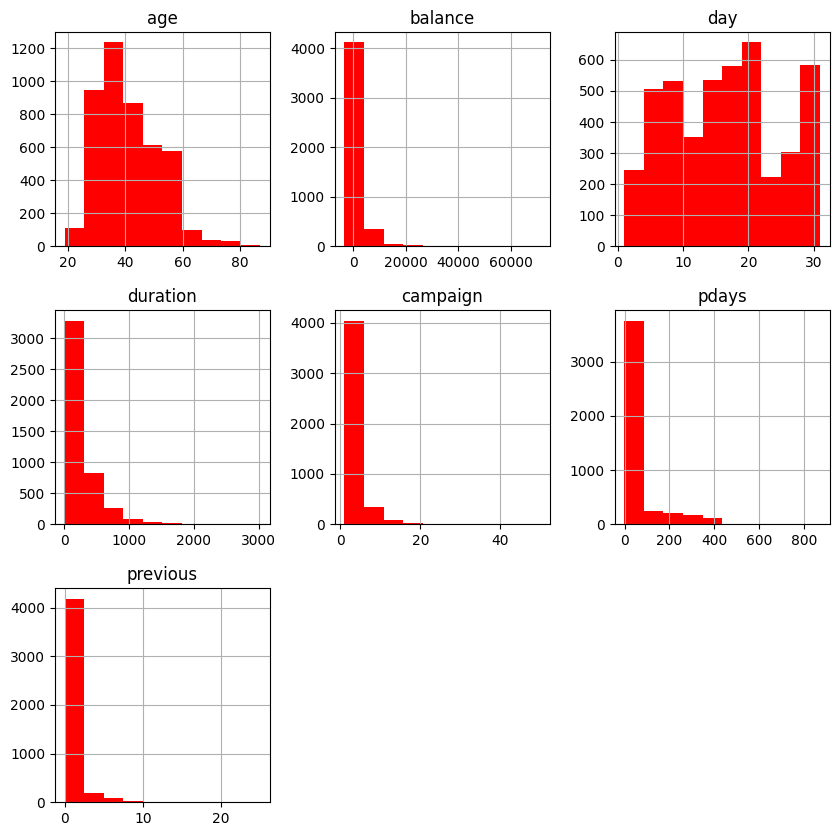

In [11]:
df.hist(figsize=(10,10),color="red")

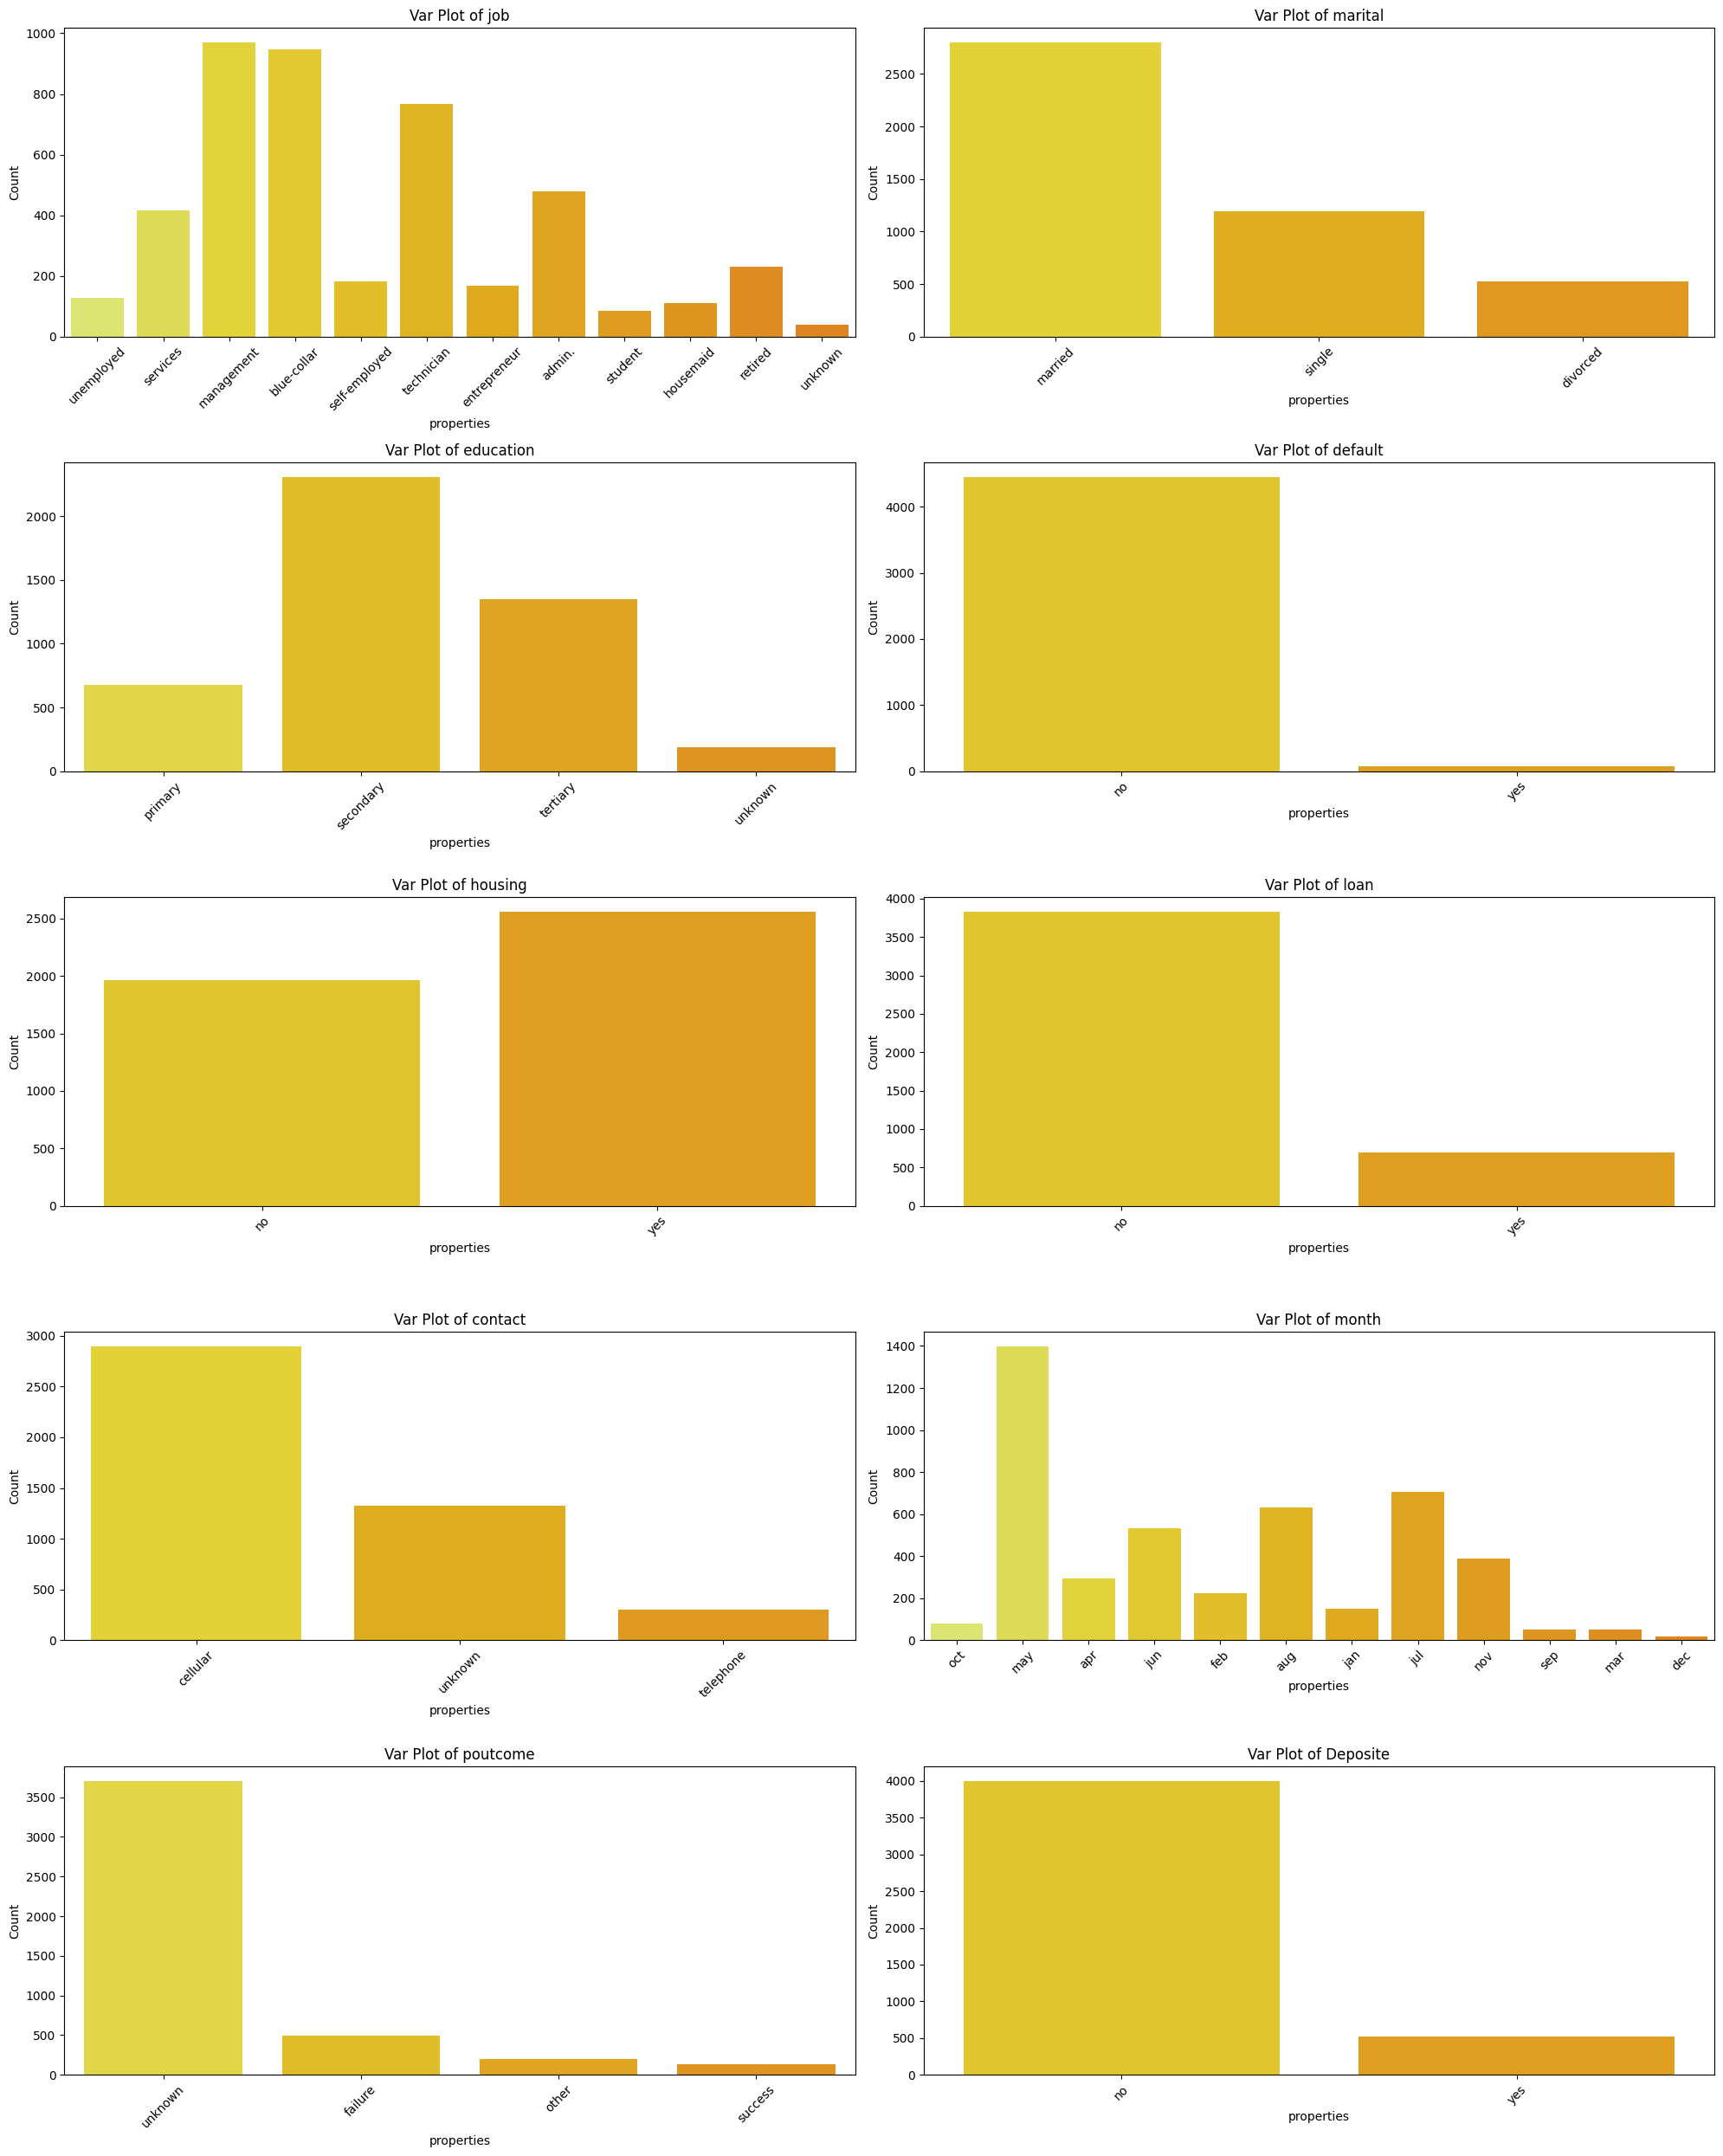

In [ ]:
num_plots = len(cat_cols)
num_rows = (num_plots + 1) // 2
num_cols = 2
plt.figure(figsize=(20, 25))

for i, feature in enumerate(cat_cols, 1):
    # 1. Changed to lowercase 's'
    plt.subplot(num_rows, num_cols, i)

    # 2. Added hue and legend to satisfy newer Seaborn versions
    sns.countplot(x=feature, data=df, palette='Wistia', hue=feature, legend=False)

    plt.title(f'Var Plot of {feature}')
    plt.xlabel('properties')
    plt.ylabel('Count')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


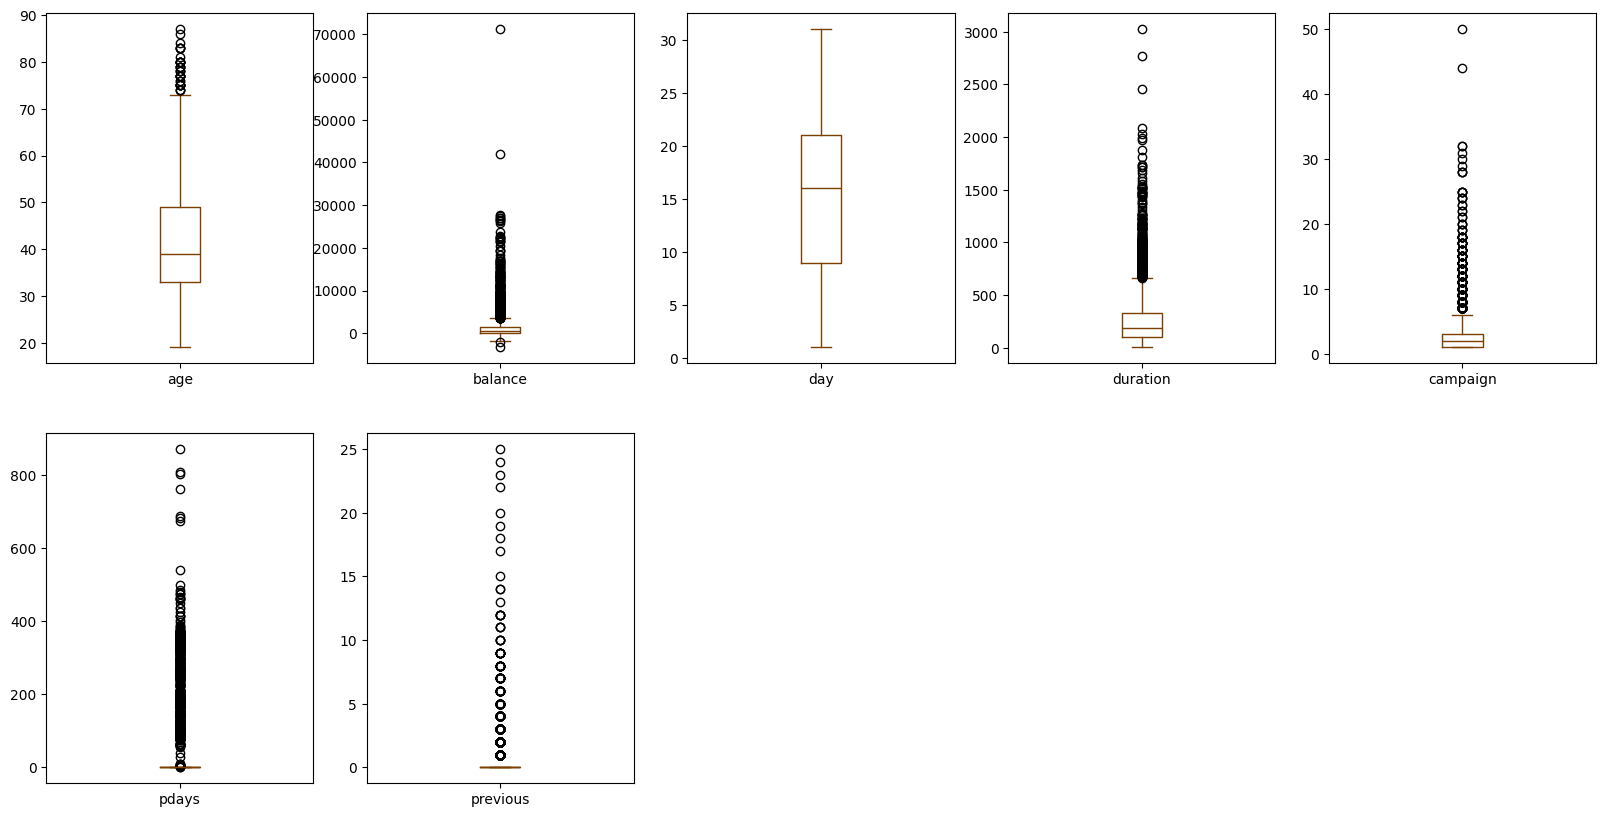

In [17]:
df.plot(kind='box',subplots=True, layout=(2,5), figsize=(20,10), color='#7b3f00')
plt.show()

In [ ]:
column = df[['age','campaign','duration']]
q1 = np.percentile(column,25)
q3 = np.percentile(column,75)
iqr = q3 - q1
lower_bound = q1 - 1.5*iqr
upper_bound = q3 + 1.5*iqr
df[['age','campain','duration']] = column[(column > lower_bound) & (column > upper_bound)]

age            Axes(0.125,0.53;0.133621x0.35)
balance     Axes(0.285345,0.53;0.133621x0.35)
day          Axes(0.44569,0.53;0.133621x0.35)
duration    Axes(0.606034,0.53;0.133621x0.35)
campaign    Axes(0.766379,0.53;0.133621x0.35)
pdays          Axes(0.125,0.11;0.133621x0.35)
previous    Axes(0.285345,0.11;0.133621x0.35)
campain      Axes(0.44569,0.11;0.133621x0.35)
dtype: object

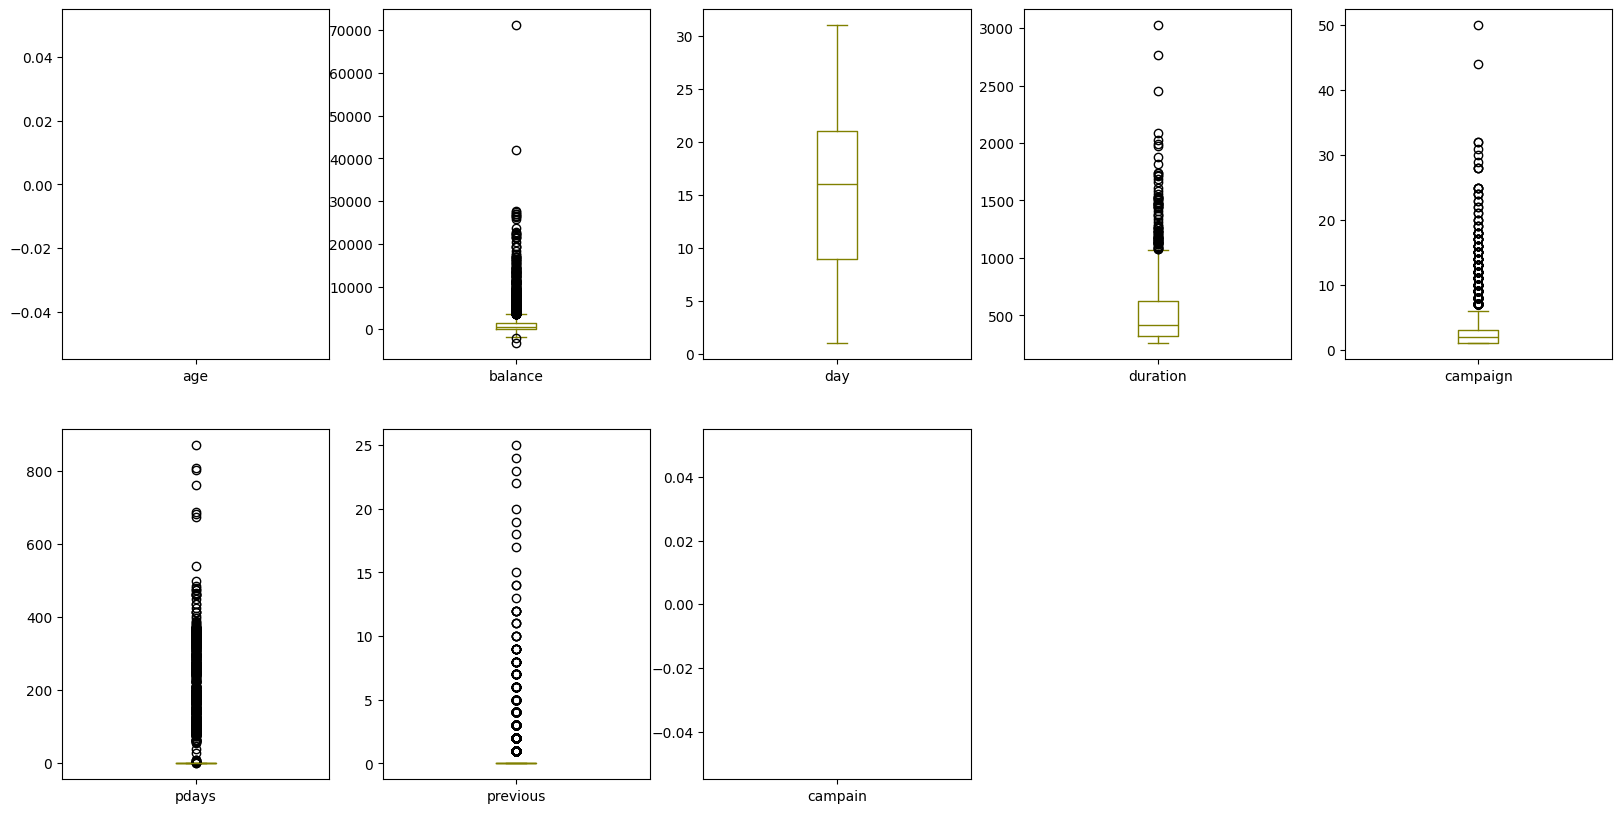

In [19]:
df.plot(kind='box',subplots=True,layout=(2,5),figsize=(20,10),color="#808000")

          age   balance       day  duration  campaign     pdays  previous  \
age       NaN       NaN       NaN       NaN       NaN       NaN       NaN   
balance   NaN  1.000000 -0.008677 -0.054701 -0.009976  0.009437  0.026196   
day       NaN -0.008677  1.000000  0.028140  0.160706 -0.094352 -0.059114   
duration  NaN -0.054701  0.028140  1.000000  0.060783 -0.010963  0.001681   
campaign  NaN -0.009976  0.160706  0.060783  1.000000 -0.093137 -0.067833   
pdays     NaN  0.009437 -0.094352 -0.010963 -0.093137  1.000000  0.577562   
previous  NaN  0.026196 -0.059114  0.001681 -0.067833  0.577562  1.000000   
campain   NaN       NaN       NaN       NaN       NaN       NaN       NaN   

          campain  
age           NaN  
balance       NaN  
day           NaN  
duration      NaN  
campaign      NaN  
pdays         NaN  
previous      NaN  
campain       NaN  


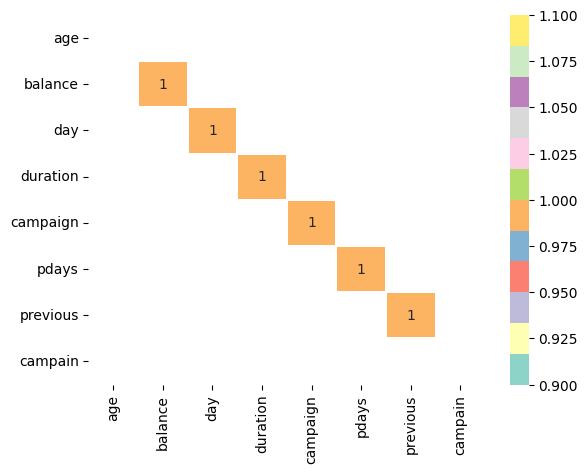

In [20]:
numeric_df = df.drop(columns=cat_cols)
corr = numeric_df.corr()
print(corr)
corr = corr[abs(corr) >= 0.90]
sns.heatmap(corr,annot=True,cmap='Set3',linewidths=0.2)
plt.show()

In [26]:
high_corr_cols = ['emp.var.rate','euribor3m','nr.employed']

In [27]:
df1 = df.copy()
df1.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'Deposite', 'campain'],
      dtype='object')

In [29]:
df1.shape

(4521, 18)

In [33]:
from sklearn.preprocessing import LabelEncoder
lb = LabelEncoder()
df_encoded = df1.apply(lb.fit_transform)
df_encoded

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,Deposite,campain
0,0,10,1,0,0,1475,0,0,0,18,10,623,0,0,0,3,0,0
1,0,7,1,1,0,2030,1,1,0,10,8,623,0,228,4,0,0,0
2,0,4,2,2,0,1303,1,0,0,15,0,623,0,219,1,0,0,0
3,0,4,1,2,0,1352,1,1,2,2,6,623,3,0,0,3,0,0
4,0,1,1,1,0,274,1,0,2,4,8,623,0,0,0,3,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,0,7,1,1,0,119,1,0,0,29,5,73,4,0,0,3,0,0
4517,0,6,1,2,1,0,1,1,2,8,8,623,0,0,0,3,0,0
4518,0,9,1,1,0,558,0,0,0,18,1,623,10,0,0,3,0,0
4519,0,1,1,1,0,1187,0,0,0,5,3,623,3,140,3,1,0,0


In [36]:
df_encoded['Deposite'].value_counts()


Deposite
0    4000
1     521
Name: count, dtype: int64

In [39]:
x = df_encoded.drop('Deposite',axis=1)
y = df_encoded['Deposite']
print(x.shape)
print(y.shape)
print(type(x))
print(type(y))

(4521, 17)
(4521,)
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


In [40]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=1)
print(x_train.shape)
print(x_test.shape)
print(y_train)
print(y_test)

(3390, 17)
(1131, 17)
4109    0
693     0
1958    0
3791    0
2053    0
       ..
2895    0
2763    0
905     1
3980    0
235     0
Name: Deposite, Length: 3390, dtype: int64
1236    0
2183    0
1573    0
4489    0
1801    0
       ..
666     0
171     0
2102    0
2424    0
3749    0
Name: Deposite, Length: 1131, dtype: int64


In [47]:
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
def eval_model(y_test,y_pred):
    acc = accuracy_score(y_test,y_pred)
    cm = confusion_matrix(y_test,y_pred)
    print('confusion Matrix\n',cm)
    print('confusion Matrix\n',classification_report(y_test,y_pred))

In [62]:
def mscore(model):
    train_score = model.score(x_train,y_train)
    test_score = model.score(x_test,y_test)
    print('Training Score',train_score)
    print('Testing Score',test_score)

In [63]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(criterion ='gini',max_depth=5,min_samples_split =10)
dt.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [64]:
mscore(dt)

Training Score 0.9171091445427728
Testing Score 0.883289124668435


In [65]:
ypred_dt = dt.predict(x_test)
print(ypred_dt)

[0 0 0 ... 0 0 0]


In [66]:
eval_model(y_test,ypred_dt)

confusion Matrix
 [[943  45]
 [ 87  56]]
confusion Matrix
               precision    recall  f1-score   support

           0       0.92      0.95      0.93       988
           1       0.55      0.39      0.46       143

    accuracy                           0.88      1131
   macro avg       0.73      0.67      0.70      1131
weighted avg       0.87      0.88      0.87      1131



In [67]:
from sklearn.tree import plot_tree

In [68]:
cn = ['no','yes']
fn = x_train.columns
print(fn)
print(cn)

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'campain'],
      dtype='object')
['no', 'yes']


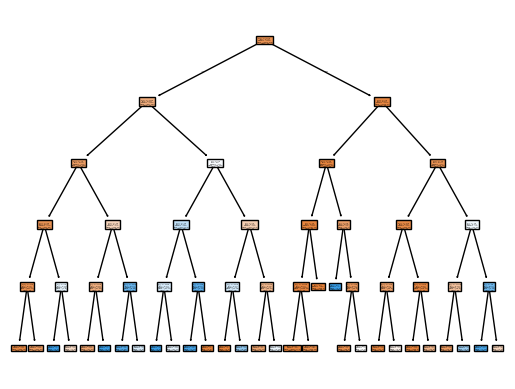

In [69]:
plt.Figure(figsize=(30,10))
plot_tree(dt,class_names=cn,filled=True)
plt.show()

In [74]:
dt1 = DecisionTreeClassifier(criterion='entropy', max_depth=4,min_samples_split=15)
dt1.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",15
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curr

In [75]:
mscore(dt1)

Training Score 0.9088495575221239
Testing Score 0.8815207780725022


In [76]:
ypred_dt1 = dt1.predict(x_test)

In [77]:
eval_model(y_test,ypred_dt1)

confusion Matrix
 [[942  46]
 [ 88  55]]
confusion Matrix
               precision    recall  f1-score   support

           0       0.91      0.95      0.93       988
           1       0.54      0.38      0.45       143

    accuracy                           0.88      1131
   macro avg       0.73      0.67      0.69      1131
weighted avg       0.87      0.88      0.87      1131



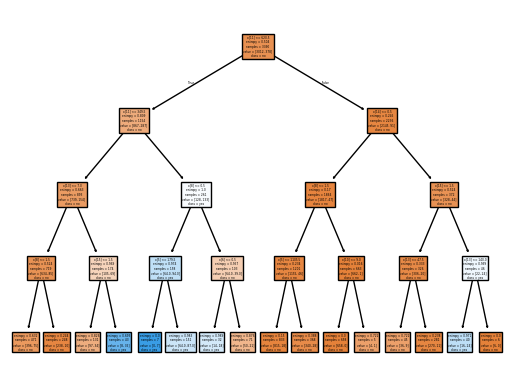

In [78]:
plt.Figure(figsize=(40,20))
plot_tree(dt1,class_names=cn,filled=True)
plt.show()